In [3]:
import pandas as pd

df_train = pd.read_csv("../data/train_clean.csv")
df_test = pd.read_csv("../data/test_clean.csv")

print(f"Train size: {len(df_train)}")
print(f"Test size: {len(df_test)}")
df_train.head()

Train size: 120000
Test size: 7600


,text,label,label_name,text_length,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business,144,wall st bears claw back into the black reuters...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business,266,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business,232,oil and economy cloud stocks outlook reuters r...
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business,256,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...",2,Business,234,oil prices soar to alltime record posing new m...


In [4]:
x_train= df_train["clean_text"]
x_test = df_test["clean_text"]

y_train = df_train["label"]
y_test = df_test["label"]

print("X_train sample:", x_train.iloc[0])
print("Y_train sample:", y_train.iloc[0])

X_train sample: wall st bears claw back into the black reuters reuters shortsellers wall streets dwindlingband of ultracynics are seeing green again
Y_train sample: 2


In [ ]:
#Building the TF-IDF + Logistic Regression pipeline
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features = 50000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=1000, C=5))
])

print("Pipeline created")

Pipeline created1


In [9]:
import time

start =time.time()
pipeline.fit(x_train, y_train)
elapsed = time.time() - start

print(f"Training done in {elapsed:.1f} seconds")

Training done in 67.0 seconds


In [10]:
from sklearn.metrics import classification_report, accuracy_score

label_names = ["World", "Sports", "Buiseness", "Sci/Tech"]

y_pred = pipeline.predict(x_test)

acc= accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names = label_names))

Accuracy: 0.9191

              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.96      0.98      0.97      1900
   Buiseness       0.89      0.89      0.89      1900
    Sci/Tech       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



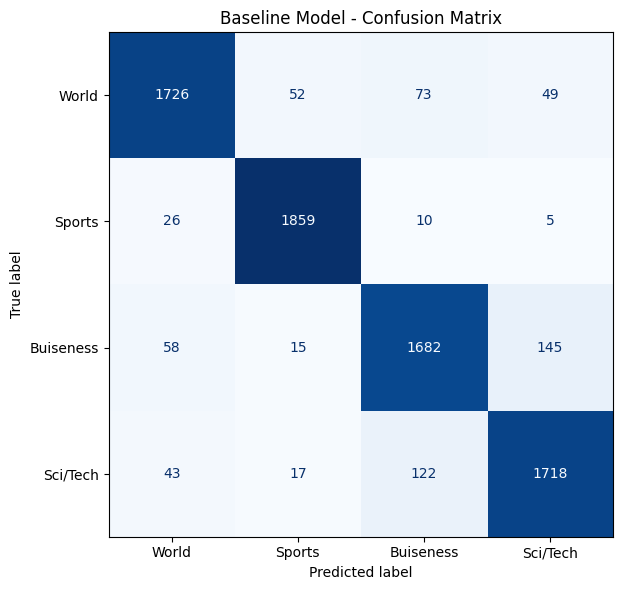

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = label_names)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, colorbar = False, cmap="Blues")
plt.title("Baseline Model - Confusion Matrix")
plt.tight_layout()
plt.savefig("../data/baseline_confusion_matrix.png")
plt.show()

In [15]:
import joblib
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(pipeline, "../models/baseline_model.pk1")

print("Model saved to models/baseline_model.pk1")

Model saved to models/baseline_model.pk1
